# Basic Health Insurance in The Netherlands - Statistical Analysis of the Average Cost per person at Different Levels of Income

This small project aimed to investigate if the average cost per person in The Netherlands with basic health insurance differs accross the different levels of income in the population, and also during the period of 2009 - 2023. Two types of costs were investigated; i) Hospital care (Ziekenhuiszorg) and ii) Pharmacy costs (Farmacie).

This information is important to understand if there is eventually a relation between these costs and the different income groups, as well as if there has been any significant trend for all the income groups accross the years.

The dataset used in this project is publicly available at the Centraal Bureau voor de Statistiek (CBS), and it can be downloaded here: (https://opendata.cbs.nl/#/CBS/nl/dataset/81827NED/table?ts=1774895242480)


In [1]:
# Import Libraries

import os
import pandas as pd
from scipy.stats import zscore
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#% LOADING DATA - "Basisverzekering (Zvw); kosten per persoon, inkomen" CSV file

# Setting up current path that contains the downloaded CSV file from CBS
folder_path = os.getcwd()

# Importing the CSV data file downloaded from CBS
csv_filename = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f)) and f.lower().endswith(".csv")]
csv_filename = [os.path.join(folder_path, filename) for filename in csv_filename]
raw_data = pd.read_csv(csv_filename[0], delimiter=";")

 # 2-WAY ANALYSIS OF VARIANCE (ANOVA)

ANOVA to assess if the different income ranges (Gestandaardiseerd inkomen) and year (Perioden) have an effect on the averaged hospital and pharmaceutical costs per person.


In [3]:
# Data pre-processing:

# removing the rows in the "raw_data" that are not part of the statistical analysis 
data_anova = raw_data[~raw_data["Gestandaardiseerd inkomen"].str.contains("Totaal alle inkomens", case=False, na=False)]

# renaming columns to overcome limitations in anova function
data_anova = data_anova.rename(columns={
    "Gemiddelde zorgkosten volgens de Zvw (euro)": "zorgkosten",
    "Gestandaardiseerd inkomen": "inkomen"
})

[['Outlier(s) identified at row(s):', '[29]']]
                   sum_sq     df           F        PR(>F)
C(inkomen)   1.646811e+06    9.0  303.062516  7.105767e-81
C(Perioden)  2.759528e+06   14.0  326.465974  1.024287e-91
Residual     7.607456e+04  126.0         NaN           NaN
Shapiro-Wilk p-value: 0.00015247332135481337


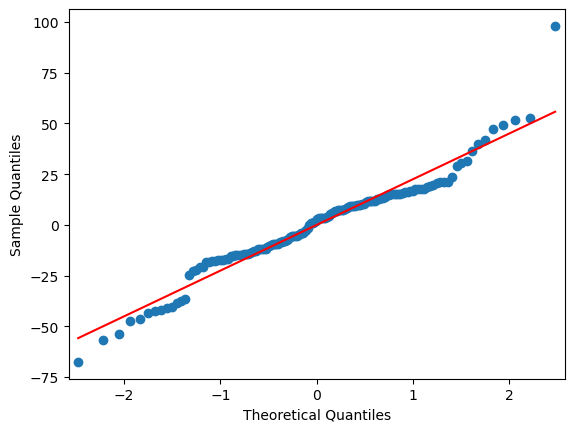

In [4]:
# --> Performing ANOVA for Hospital care (Ziekenhuiszorg) costs

data_anova_ziekenhuiszorg = data_anova[(data_anova["Zorgvorm Zvw-zorgkosten"] == "Ziekenhuiszorg")]

# Checking for outliers before ANOVA
z_score_ziekenhuiszorg = zscore(data_anova_ziekenhuiszorg["zorgkosten"], nan_policy='omit')
outliers_ziekenhuiszorg = abs(z_score_ziekenhuiszorg) > 3
print(["NO OUTLIERS (z-score > 3) IDENTIFIED" if sum(outliers_ziekenhuiszorg) == 0 else 
       ["Outlier(s) identified at row(s):", str([index for index, value in enumerate(outliers_ziekenhuiszorg) if value])]])


# Fit 2-way ANOVA model - no interaction term added due to the lack of sample replicates (no degrees of freedom to estimate residuals 
# in the presence of the interaction term) 
anova_model_ziekenhuiszorg = ols('zorgkosten ~ C(inkomen) + C(Perioden)', data=data_anova_ziekenhuiszorg).fit()
residuals_ziekenhuiszorg = anova_model_ziekenhuiszorg.resid
anova_table_ziekenhuiszorg = anova_lm(anova_model_ziekenhuiszorg, typ=2)
print(anova_table_ziekenhuiszorg)

# Q-Q Residuals Plot
sm.qqplot(residuals_ziekenhuiszorg, line="s")

# Testing for normality of the residuals
shapiro_stat_ziekenhuiszorg, shapiro_p_ziekenhuiszorg = shapiro(residuals_ziekenhuiszorg)
print("Shapiro-Wilk p-value:", shapiro_p_ziekenhuiszorg)

The anova table for the model above (zorgkosten ~ C(inkomen) + C(Perioden)) shows that both the income groups and the period have a strong effect on the hospital care costs (p-value << 0.01). Despite there is indication that the residuals do not follow a normal distribution (Shapiro-Wilk p-value < 0.05), which is a general pre-requisite for anova, the Q-Q plot does not show strong deviations from a random distribution across the theoretical quantiles line. One outlier has been identified (z-score = 3.71); however it was not removed from the data to not break the symmetry with respect to the combinations of the factors (inkomen and Perioden), once there are no replicates, leading to less degrees of freedom for the mean squares estimations.

['NO OUTLIER (z-score > 3) WERE IDENTIFIED']
                    sum_sq     df           F        PR(>F)
C(inkomen)   326601.206667    9.0  431.641330  3.609561e-90
C(Perioden)   56981.173333   14.0   48.411785  8.755102e-44
Residual      10593.093333  126.0         NaN           NaN
Shapiro-Wilk p-value: 0.0002723835843678365


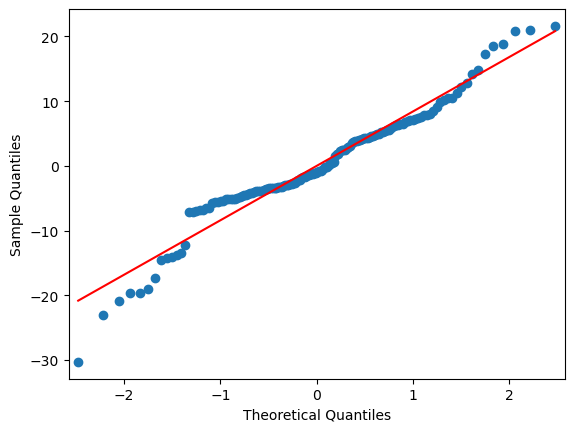

In [5]:
# --> Farmacie - also only aditive terms

data_anova_farmacie = data_anova[(data_anova["Zorgvorm Zvw-zorgkosten"] == "Farmacie")]

# Checking for outliers before ANOVA
z_score_farmacie = zscore(data_anova_farmacie["zorgkosten"], nan_policy='omit')
outliers_farmacie = abs(z_score_farmacie) > 3
print(["NO OUTLIER (z-score > 3) WERE IDENTIFIED" if sum(outliers_farmacie) == 0 else 
       ["Outlier identified at row:", str([index for index, value in enumerate(outliers_farmacie) if value])]])


# Fit 2-way ANOVA model - no interaction term added due to the lack of sample replicates 
# (no degrees of freedom to estimate residuals in the presence of the interaction term) 

anova_model_farmacie = ols('zorgkosten ~ C(inkomen) + C(Perioden)', data=data_anova_farmacie).fit()
residuals_farmacie = anova_model_farmacie.resid
anova_table_farmacie = anova_lm(anova_model_farmacie, typ=2)

print(anova_table_farmacie)

# Q-Q Residuals Plot
sm.qqplot(residuals_farmacie, line="s")

# Testing for normality of the residuals
shapiro_stat_farmacie, shapiro_p_farmacie = shapiro(residuals_farmacie)
print("Shapiro-Wilk p-value:", shapiro_p_farmacie)

The same conclusion can be obtained from the anova table and the residuals normality test when assessing the pharmacy costs. Here no outliers were identified.

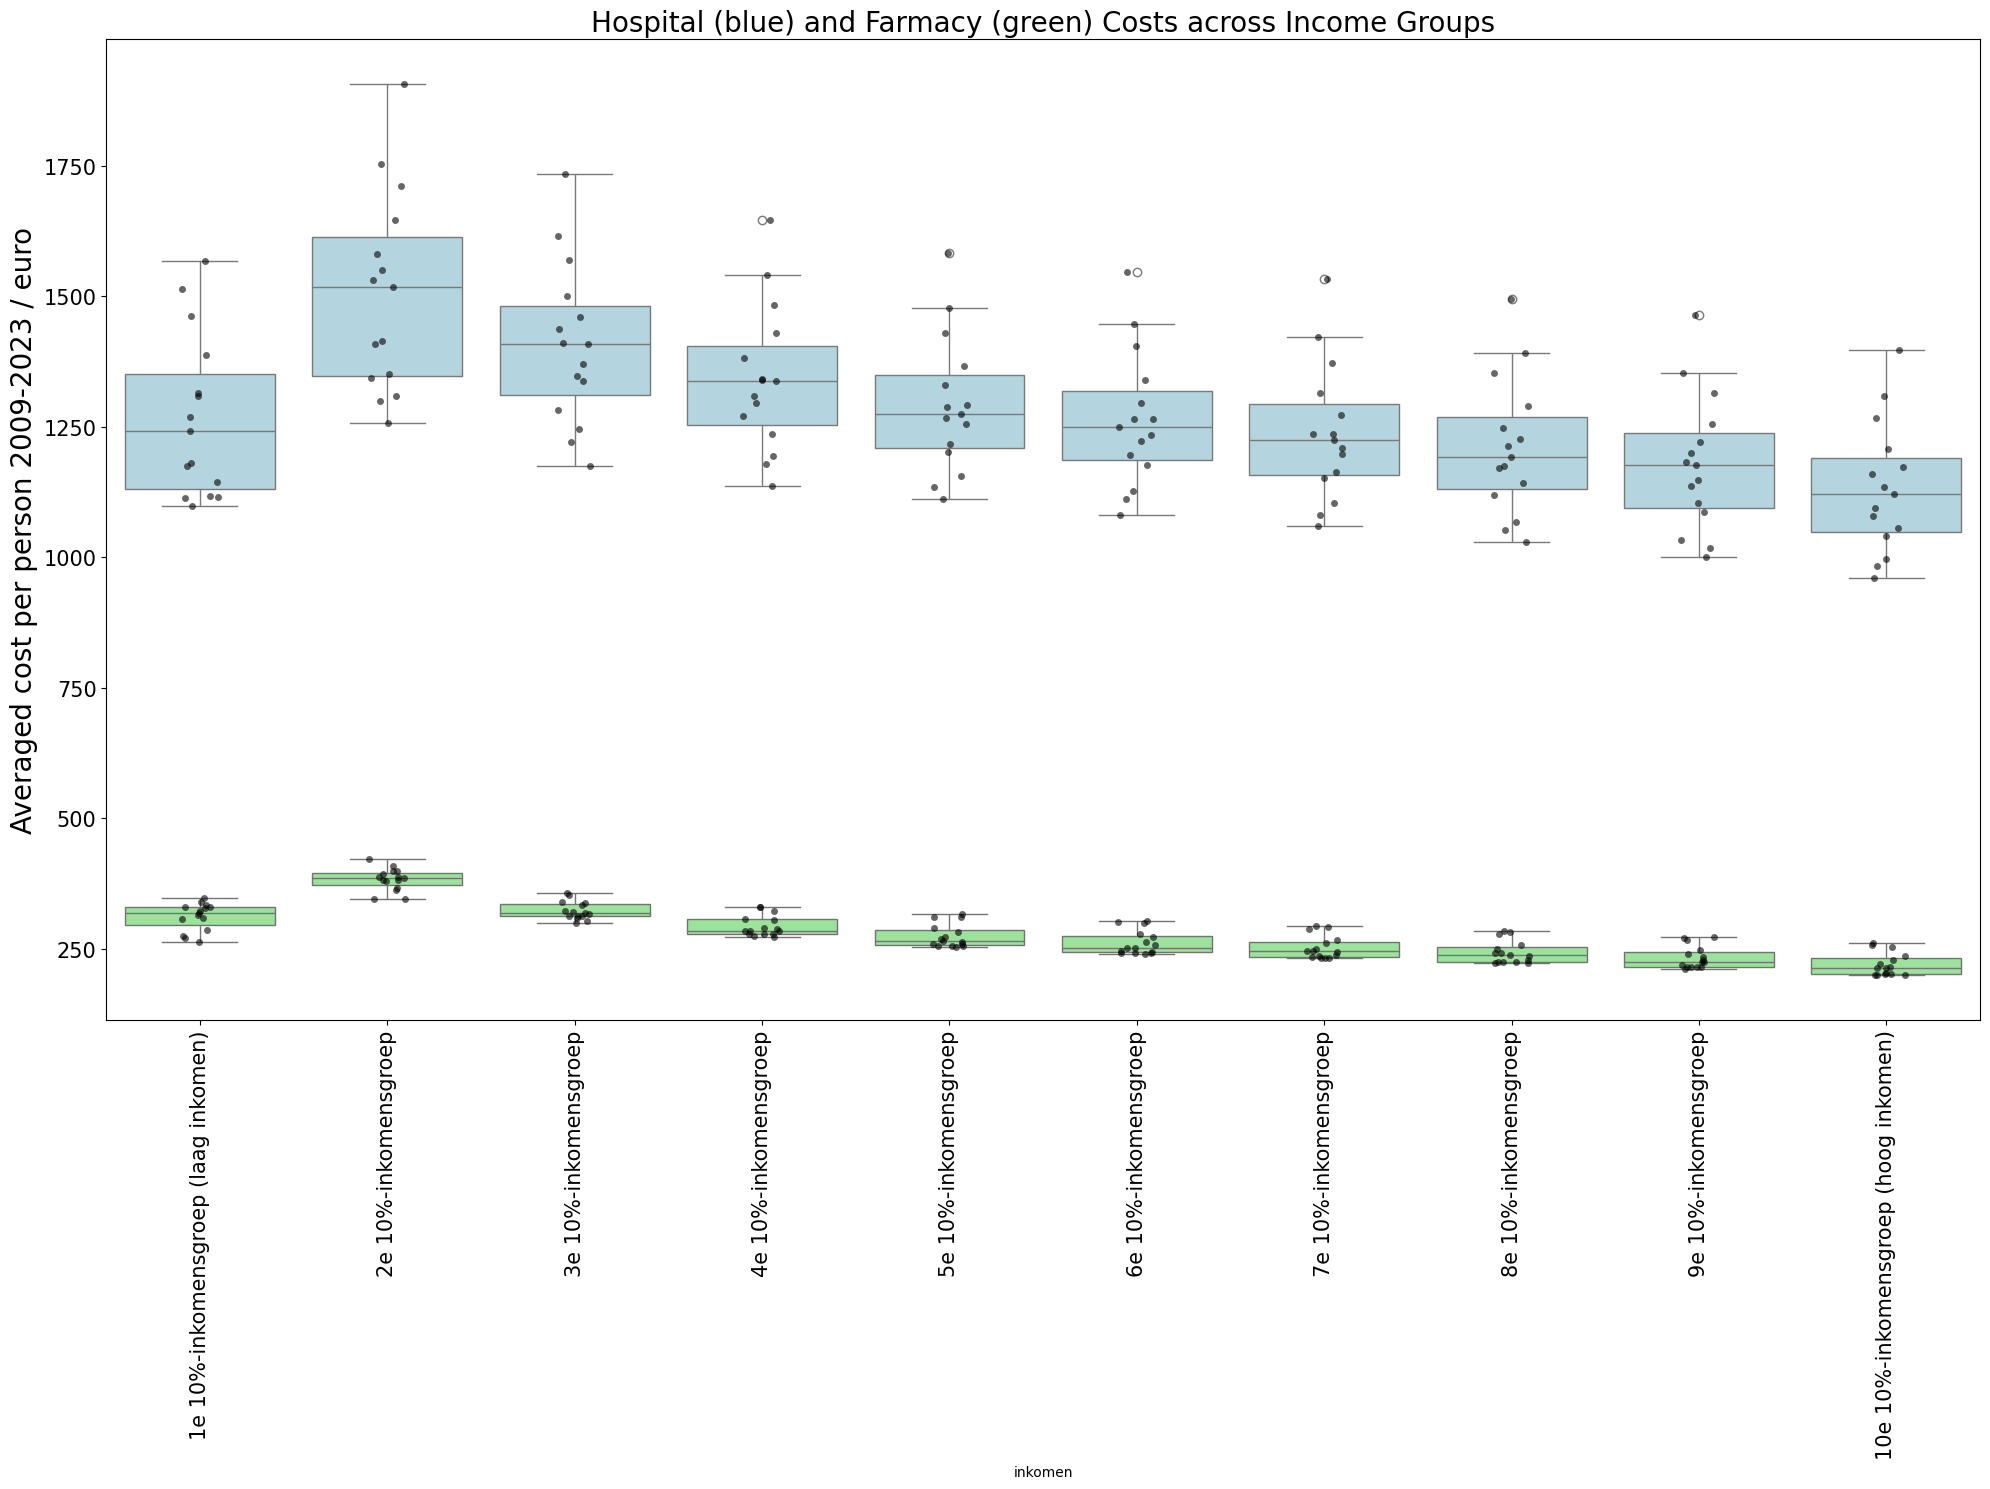

In [6]:
# Plotting Box-plots for "Ziekenhuiszorg" and "Farmacie"

plt.figure(figsize=(20, 15))
sns.boxplot(x='inkomen', y='zorgkosten', data=data_anova_ziekenhuiszorg, color='lightblue')
sns.stripplot(x='inkomen', y='zorgkosten', data=data_anova_ziekenhuiszorg, color='black', alpha=0.6)
sns.boxplot(x='inkomen', y='zorgkosten', data=data_anova_farmacie, color='lightgreen')
sns.stripplot(x='inkomen', y='zorgkosten', data=data_anova_farmacie, color='black', alpha=0.6)
plt.title('Hospital (blue) and Farmacy (green) Costs across Income Groups', fontsize=20)
plt.ylabel('Averaged cost per person 2009-2023 / euro', fontsize=20)
plt.xticks(rotation=90, fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()

The boxplots for the Income Groups show the distribution of the Hospital care and Pharmacy costs per group, highlighting that people belonging to the 2nd (highest variability within 2009 - 2023), 3rd and 4th lowest income groups have spent more on these type of costs, following a decend trend until the highest income group (least averaged costs per person).
The pharmacy costs followed the same trend, except that the variability is similar across the groups, highlighting the correlation between these 2 types of costs in healthcare.